In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC

data = pd.read_csv(r"D:\recabe\ML\credit_card class\creditcard.csv\creditcard.csv")
data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [3]:
data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [4]:
data.duplicated().sum()

1081

In [5]:
data.drop_duplicates(inplace=True)

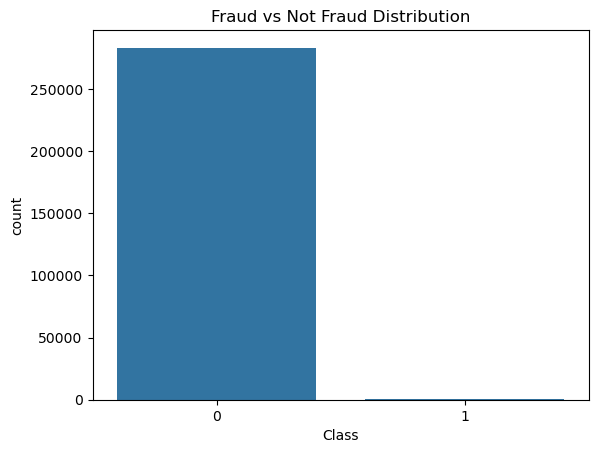

In [6]:


sns.countplot(data=data, x='Class')
plt.title("Fraud vs Not Fraud Distribution")
plt.show()


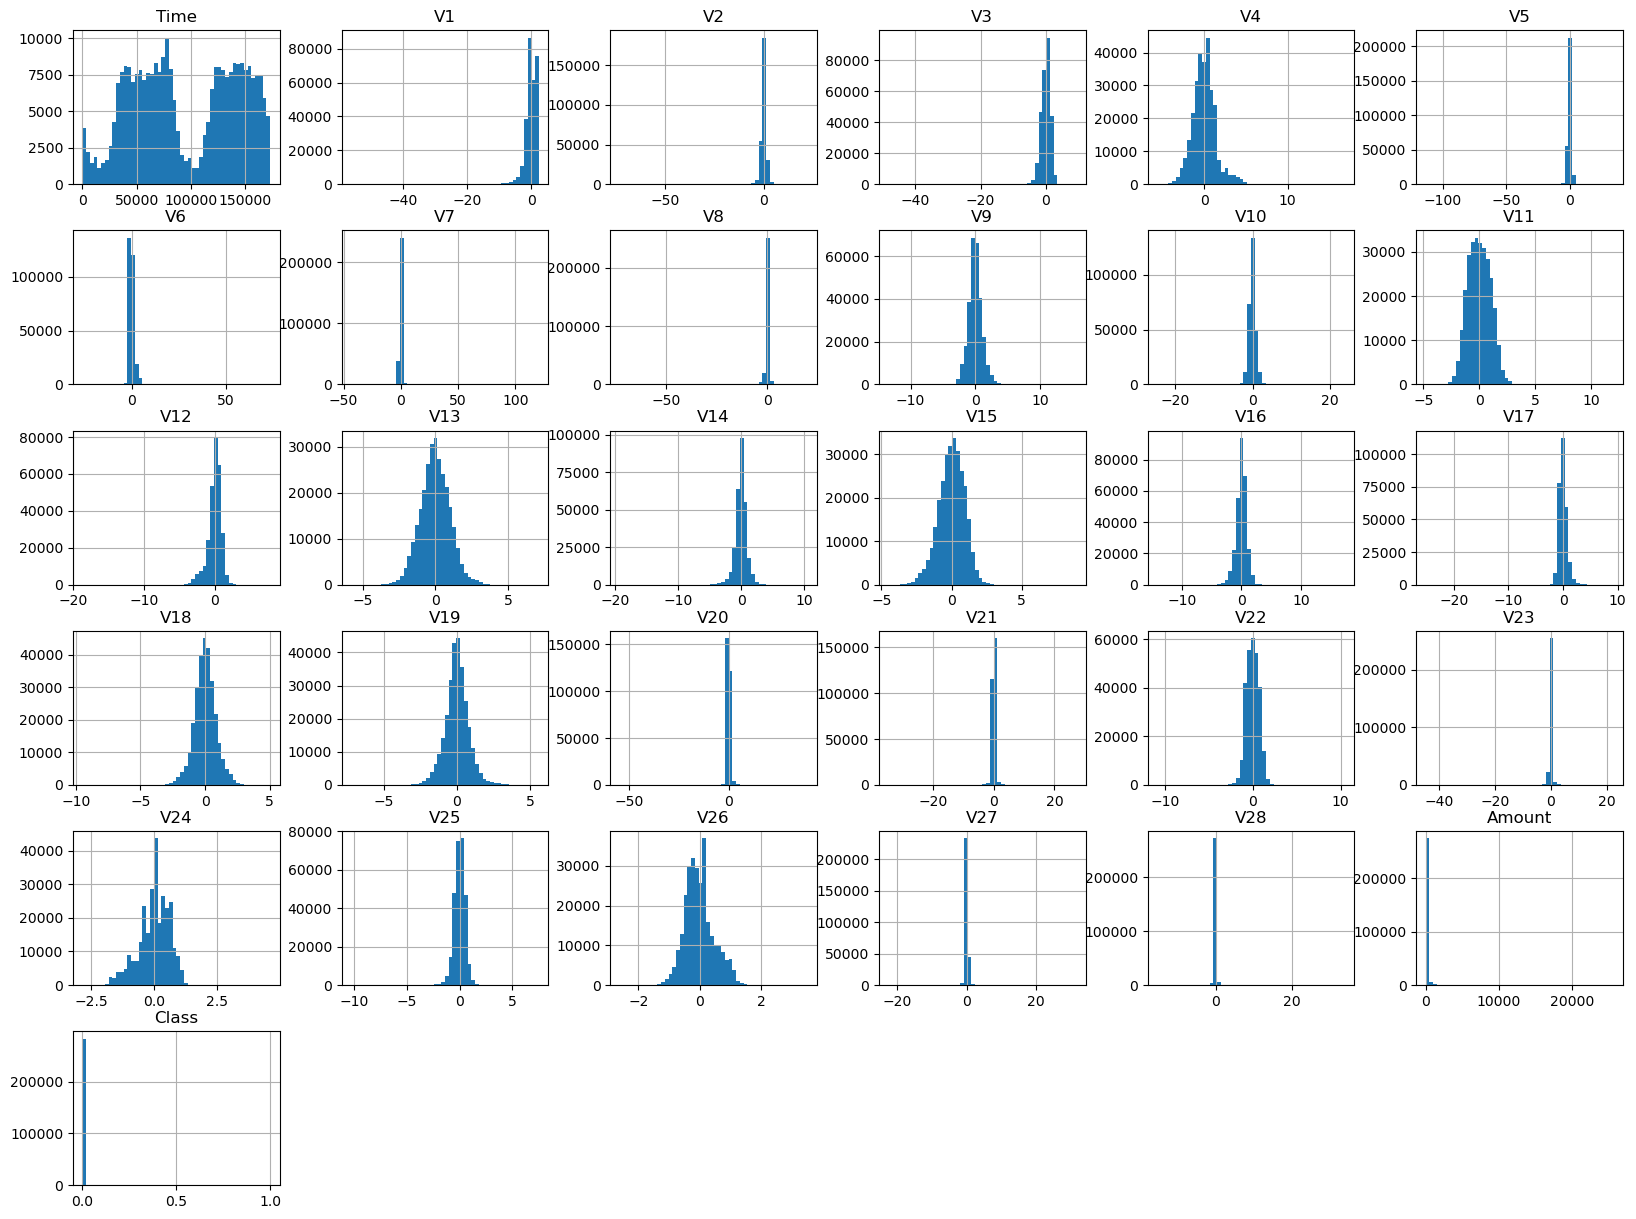

In [7]:
data.hist(figsize=(20, 15), bins=50)
plt.show()


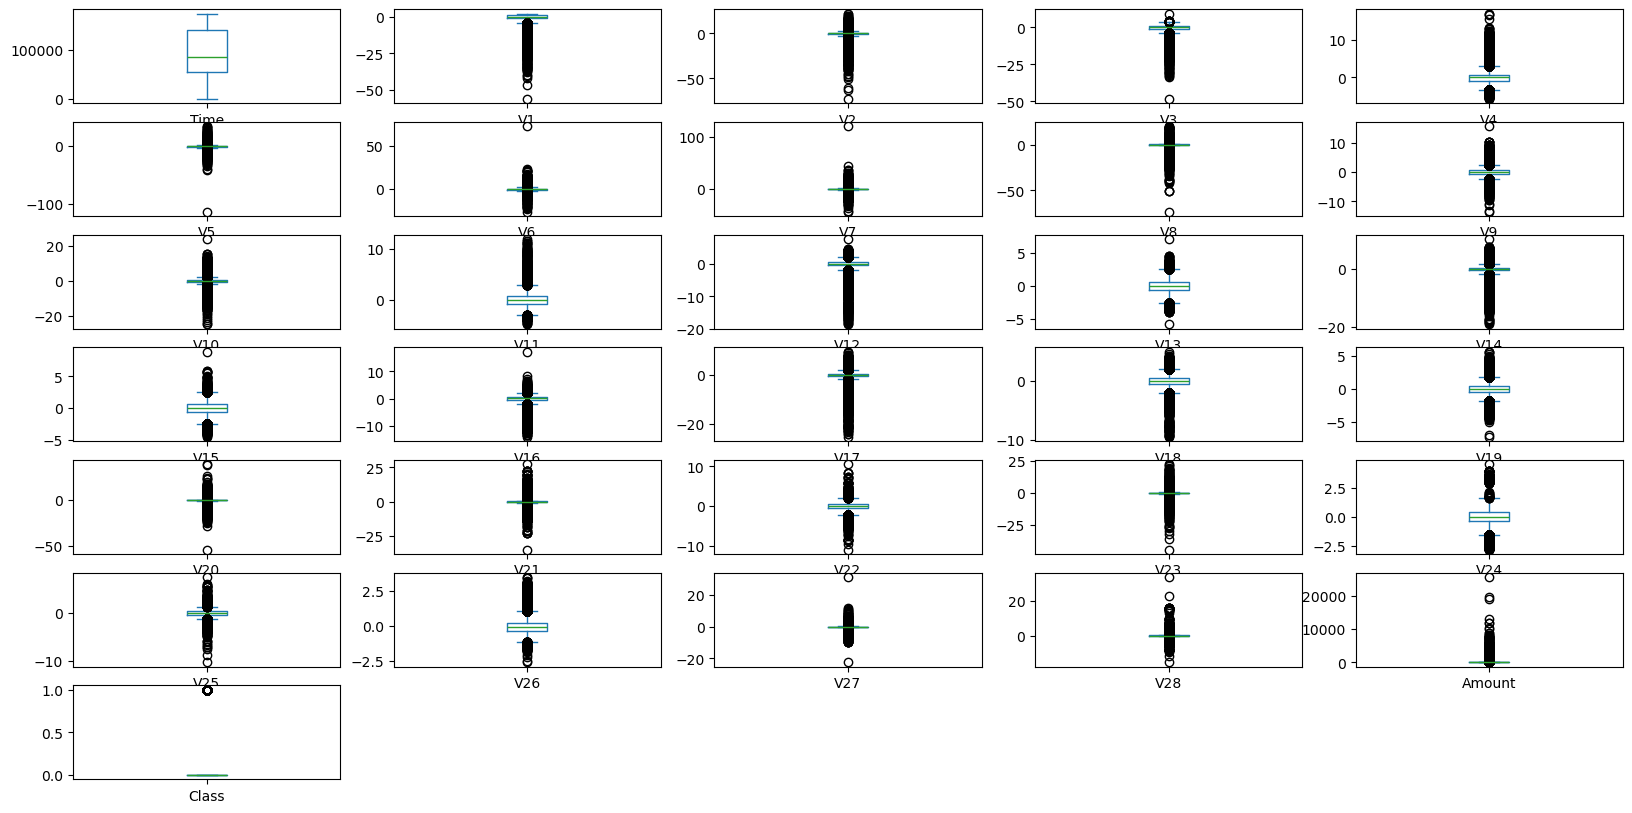

In [8]:
data.plot(kind='box', figsize=(20,10), subplots=True, layout=(7,5))
plt.show()


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 

In [10]:
corrilation= data.corr()

<Axes: >

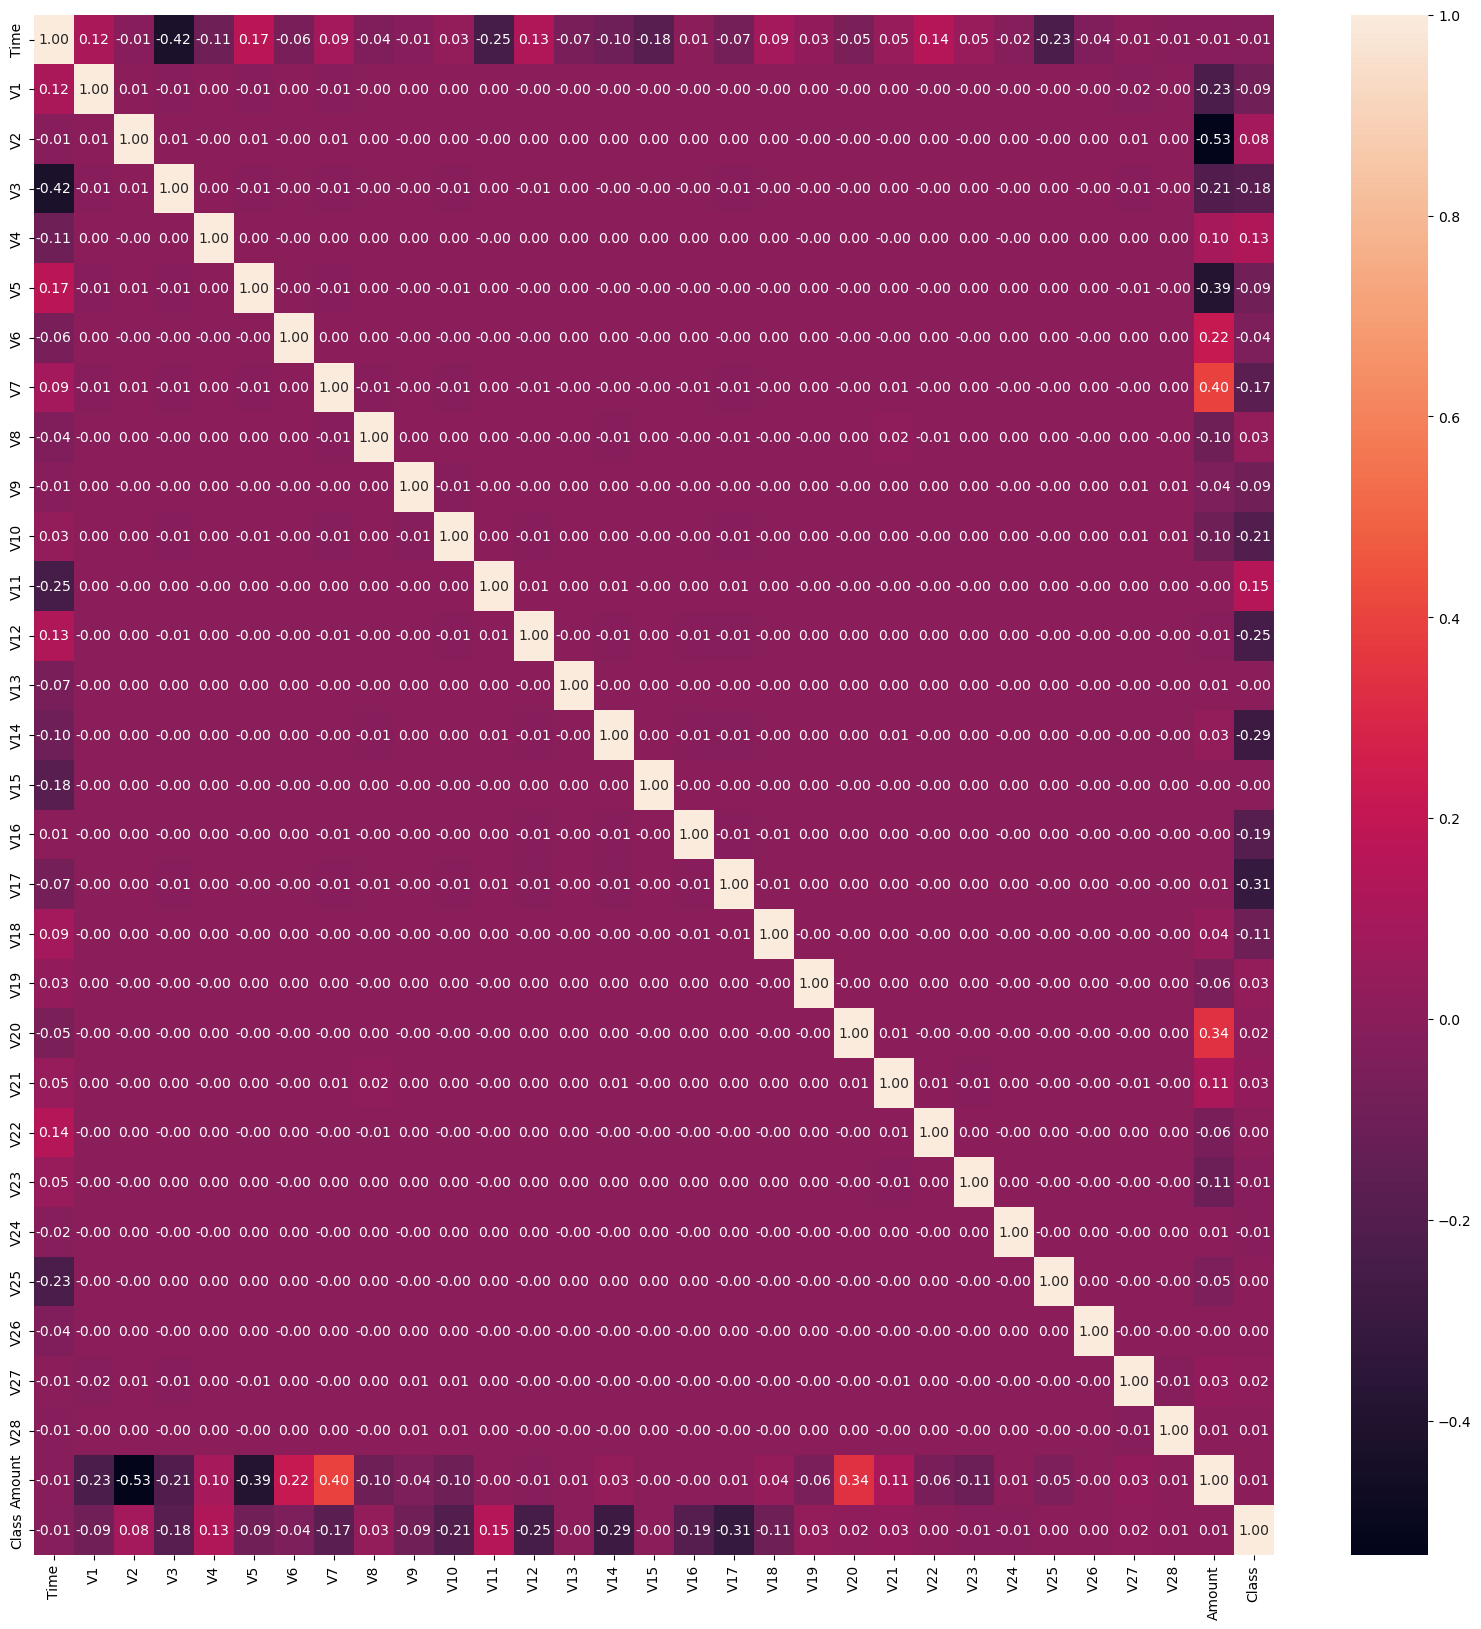

In [11]:
import seaborn as sns
plt.figure(figsize=(20,20))
sns.heatmap(corrilation,annot=True,fmt=".2f")

In [12]:
data["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [13]:

scaler=StandardScaler()
data2=data.drop("Class",axis=1).copy()
data2_scaled=scaler.fit_transform(data2)
data2_scaled = pd.DataFrame(data2_scaled, columns=data2.columns, index=data2.index)
data2_scaled["Class"]=data["Class"]
data2_scaled

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.996823,-0.701082,-0.041687,1.680101,0.976623,-0.247020,0.348012,0.193700,0.084434,0.333534,...,-0.024777,0.383483,-0.177444,0.110157,0.247059,-0.392622,0.333033,-0.065850,0.244200,0
1,-1.996823,0.608792,0.164138,0.109279,0.318998,0.042258,-0.060980,-0.065656,0.072903,-0.231703,...,-0.311372,-0.881454,0.162081,-0.561503,0.321175,0.260854,-0.027154,0.043219,-0.342584,0
2,-1.996802,-0.700336,-0.811337,1.174270,0.270648,-0.366756,1.352655,0.643223,0.210788,-1.381169,...,0.343094,1.065068,1.457772,-1.138484,-0.628161,-0.288861,-0.144325,-0.183824,1.158900,0
3,-1.996802,-0.499064,-0.109972,1.187383,-0.608355,-0.008814,0.937245,0.192079,0.320843,-1.264664,...,-0.149093,0.007299,-0.305465,-1.941446,1.242487,-0.460694,0.154039,0.185687,0.139886,0
4,-1.996781,-0.597606,0.535539,1.025470,0.287092,-0.297036,0.072873,0.481517,-0.228725,0.747917,...,-0.012516,1.101780,-0.220709,0.232904,-0.394800,1.041677,0.550001,0.654234,-0.073813,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,1.642235,-6.102103,6.118855,-6.519873,-1.459282,-3.897079,-1.956335,-4.007632,6.196662,1.749010,...,0.295375,0.154412,1.626230,-0.841382,2.757072,0.518377,2.380049,2.509507,-0.350252,0
284803,1.642257,-0.379208,-0.030938,1.347812,-0.520175,0.629193,0.795504,0.018351,0.250814,0.535282,...,0.296413,1.275826,0.019665,-1.678330,-1.163409,-0.820253,0.168567,-0.164849,-0.254325,0
284804,1.642278,0.982354,-0.180433,-2.155033,-0.392355,1.908988,2.276699,-0.243249,0.601561,0.396215,...,0.321057,0.798074,-0.060444,1.056626,0.510299,-0.181557,0.006802,-0.082640,-0.082239,0
284805,1.642278,-0.126465,0.324660,0.464577,0.489870,-0.275808,0.469130,-0.560399,0.576734,0.359367,...,0.366919,1.104223,-0.262138,0.203081,-1.091530,1.133734,0.270523,0.317004,-0.313391,0


In [14]:

X=data2_scaled.drop("Class",axis=1)
Y=data2_scaled["Class"]
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [15]:


smote = SMOTE(random_state=42)
X_train_res,Y_train_res=smote.fit_resample(X_train,Y_train)

<Axes: xlabel='Class'>

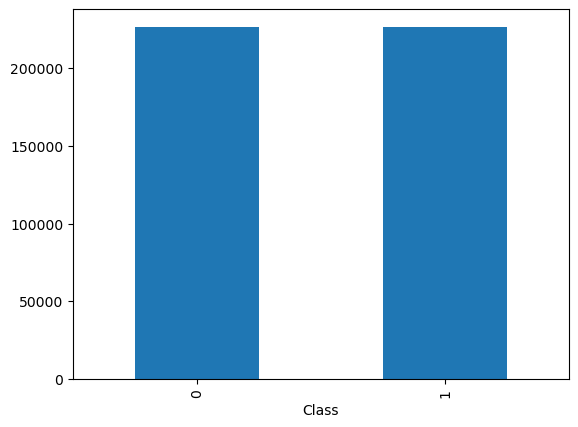

In [16]:
Y_train_res.value_counts().plot.bar(Y_train_res)

In [17]:


knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_res, Y_train_res)
y_pred = knn.predict(X_test)

from sklearn.metrics import confusion_matrix

print("KNN Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred))
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Y_test, y_pred)
print(f"Accuracy: {accuracy}")

KNN Confusion Matrix:
[[56553    98]
 [   19    76]]
Accuracy: 0.9979381806647164


In [18]:

print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.44      0.80      0.57        95

    accuracy                           1.00     56746
   macro avg       0.72      0.90      0.78     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:


X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

knn = KNeighborsClassifier(n_neighbors=3,weights='distance')
knn.fit(X_train, Y_train)
y_pred = knn.predict(X_test)

print("===== قبل SMOTE =====")
print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred))
print("Accuracy:", accuracy_score(Y_test, y_pred))
print(classification_report(Y_test, y_pred))

knn.fit(X_train_res, Y_train_res)
y_pred_res = knn.predict(X_test)

print("===== بعد SMOTE =====")
print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred_res))
print("Accuracy:", accuracy_score(Y_test, y_pred_res))
print(classification_report(Y_test, y_pred_res))


===== قبل SMOTE =====
Confusion Matrix:
[[56647     4]
 [   27    68]]
Accuracy: 0.9994537059880872
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.94      0.72      0.81        95

    accuracy                           1.00     56746
   macro avg       0.97      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746

===== بعد SMOTE =====
Confusion Matrix:
[[56577    74]
 [   22    73]]
Accuracy: 0.9983082508018186
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.50      0.77      0.60        95

    accuracy                           1.00     56746
   macro avg       0.75      0.88      0.80     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:

svm = SVC()
svm.fit(X_train, Y_train)
svmy_pred = svm.predict(X_test)

print("===== قبل SMOTE =====")
print("Confusion Matrix:")
print(confusion_matrix(Y_test, svmy_pred))
print("Accuracy:", accuracy_score(Y_test, svmy_pred))
print(classification_report(Y_test, svmy_pred))


knn.fit(X_train_res, Y_train_res)
svmy_pred_res = knn.predict(X_test)

print("===== بعد SMOTE =====")
print("Confusion Matrix:")
print(confusion_matrix(Y_test, svmy_pred_res))
print("Accuracy:", accuracy_score(Y_test, svmy_pred_res))
print(classification_report(Y_test, svmy_pred_res))


===== قبل SMOTE =====
Confusion Matrix:
[[56650     1]
 [   40    55]]
Accuracy: 0.9992774821132767
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.98      0.58      0.73        95

    accuracy                           1.00     56746
   macro avg       0.99      0.79      0.86     56746
weighted avg       1.00      1.00      1.00     56746

===== بعد SMOTE =====
Confusion Matrix:
[[56577    74]
 [   22    73]]
Accuracy: 0.9983082508018186
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.50      0.77      0.60        95

    accuracy                           1.00     56746
   macro avg       0.75      0.88      0.80     56746
weighted avg       1.00      1.00      1.00     56746



In [21]:

svm = SVC(class_weight='balanced')
svm.fit(X_train, Y_train)
svmy_pred = svm.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(Y_test, svmy_pred))
print("Accuracy:", accuracy_score(Y_test, svmy_pred))
print(classification_report(Y_test, svmy_pred))


Confusion Matrix:
[[56550   101]
 [   35    60]]
Accuracy: 0.9976033553025764
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.37      0.63      0.47        95

    accuracy                           1.00     56746
   macro avg       0.69      0.81      0.73     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:


svm = SVC(class_weight='balanced')
svm.fit(X_train_res, Y_train_res)
svmy_pred = svm.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(Y_test, svmy_pred))
print("Accuracy:", accuracy_score(Y_test, svmy_pred))
print(classification_report(Y_test, svmy_pred))


Confusion Matrix:
[[55834   817]
 [   15    80]]
Accuracy: 0.9853381736157615
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.09      0.84      0.16        95

    accuracy                           0.99     56746
   macro avg       0.54      0.91      0.58     56746
weighted avg       1.00      0.99      0.99     56746



In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, recall_score
import pandas as pd
from imblearn.over_sampling import SMOTE

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Logistic Regression (balanced)": LogisticRegression(class_weight='balanced', max_iter=1000),

    "KNN (k=3, distance)": KNeighborsClassifier(n_neighbors=3, weights='distance'),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),

    "SVM": SVC(),
    "SVM (balanced)": SVC(class_weight='balanced'),

    "Decision Tree": DecisionTreeClassifier(),
    "Decision Tree (balanced)": DecisionTreeClassifier(class_weight='balanced'),

    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Random Forest (balanced)": RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced'
    ),

    "XGBoost": XGBClassifier(
        scale_pos_weight=len(Y_train[Y_train==0]) / len(Y_train[Y_train==1]),
        eval_metric='logloss'
    )
}


In [24]:


results = []

for name, model in models.items():
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "SMOTE": "No",
        "F1-Score": f1_score(Y_test, y_pred),
        "Recall": recall_score(Y_test, y_pred)
    })


In [25]:

smote = SMOTE(random_state=42)
X_train_res, Y_train_res = smote.fit_resample(X_train, Y_train)

for name, model in models.items():
    model.fit(X_train_res, Y_train_res)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "SMOTE": "Yes",
        "F1-Score": f1_score(Y_test, y_pred),
        "Recall": recall_score(Y_test, y_pred)
    })


In [26]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-Score", ascending=False)
results_df


,Model,SMOTE,F1-Score,Recall
10,XGBoost,No,0.853801,0.768421
8,Random Forest,No,0.831325,0.726316
9,Random Forest (balanced),No,0.817073,0.705263
2,"KNN (k=3, distance)",No,0.814371,0.715789
20,Random Forest (balanced),Yes,0.813953,0.736842
19,Random Forest,Yes,0.813953,0.736842
3,KNN (k=5),No,0.790123,0.673684
4,SVM,No,0.728477,0.578947
6,Decision Tree,No,0.705882,0.694737
0,Logistic Regression,No,0.695652,0.589474


In [27]:
best_model = results_df.iloc[0]
best_model


Model        XGBoost
SMOTE             No
F1-Score    0.853801
Recall      0.768421
Name: 10, dtype: object

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, accuracy_score

xgb_no_smote = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight = (Y_train == 0).sum() / (Y_train == 1).sum(), 
    random_state=42,
    eval_metric='logloss'
)

xgb_no_smote.fit(X_train, Y_train)
y_pred_no = xgb_no_smote.predict(X_test)




In [30]:
print("===== XGBoost (No SMOTE) =====")
print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred_no))


===== XGBoost (No SMOTE) =====
Confusion Matrix:
[[56646     5]
 [   20    75]]


In [31]:
print("Accuracy:", accuracy_score(Y_test, y_pred_no))
print("F1-score:", f1_score(Y_test, y_pred_no))
print("Recall:", recall_score(Y_test, y_pred_no))


Accuracy: 0.9995594403129736
F1-score: 0.8571428571428571
Recall: 0.7894736842105263


In [34]:
print("XGBoost (No SMOTE)classification report\n",classification_report(Y_test, y_pred_no))

XGBoost (No SMOTE)classification report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.94      0.79      0.86        95

    accuracy                           1.00     56746
   macro avg       0.97      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
sample = X.iloc[0:1]   
pred = xgb_no_smote.predict(sample)
prob = xgb_no_smote.predict_proba(sample)[:,1]

print("Prediction:", pred[0])
print("Fraud Probability:", prob[0])


Prediction: 0
Fraud Probability: 0.00022931008
